# **MAT 4373: Project** </br> L1 vs. L2 regularization

## **Group members**
**Group 3**

| Name | Student ID |
|------|------------|
| Zixin Fan | 300296371 |
| Sophie Séguin | 300225009 | 
|  |  | 
|  |  | 

## **Task distribution**
- Zixin Fan
  - Synthetic dataset generation and experimental setup.
  - Analysis of predictive performance, parameter estimation accuracy, and variable selection performance.
  - High-dimensional regime (d > n) – analysis of model behaviour, explanation of ridge uniqueness and lasso sparsity, and evaluation of prediction error and support recovery.
  - Slides preparation and participation in code testing and validation.
-

## **Libraries and Packages**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from data_generation import generate_sparse_linear_data

## **Synthetic dataset generation**

### **An independent Gaussian design**
We generate synthetic data from a sparse linear model: y = Xw* + ε

where:
- X ~ N(0, I), a design matrix with entries drawn from a standard normal distribution,
- w* is sparse, a coefficient vector with only s << d nonzero entries,
- ε ~ N(0, σ²), Gaussian noise.

This dataset serves as a baseline setting for evaluating Ridge and Lasso regression in terms of prediction accuracy, parameter estimation, and support recovery.

#### **Data Generation Function:**
- sample size: n = 1000

    Larger n generally improves estimation accuracy and prediction performance.

- number of features: d = 50

    Higher d increases model complexity and makes variable selection more challenging.

- number of nonzero coefficients in w*: s = 5

    The sparsity level is s/d = 5/50 = 0.1, meaning only a small subset of variables are relevant.

- standard deviation of the Gaussian noise: sigma=1.0

    Larger sigma leads to noisier observations and makes recovery harder.

- magnitude of the nonzero coefficients in w*: signal = 2.0

     Stronger signal makes it easier to identify the true support.

- seed for reproducibility: random_seeds = 100

In [7]:
# baseline dataset generated using default parameter settings
X,y,w_true,non0=generate_sparse_linear_data(n=1000,d=50,s=5,sigma=1.0,signal=2.0,random_seeds=100)

#### **Check of Generated Data**

In [8]:
print("X shape:",X.shape)
print("y shape:",y.shape)
print("nonzero positions:",non0)
print("number of nonzero coefficients:",np.sum(w_true!=0))
print("w_true:",w_true)

X shape: (1000, 50)
y shape: (1000,)
nonzero positions: [10  3  5 18 12]
number of nonzero coefficients: 5
w_true: [ 0.  0.  0. -2.  0.  2.  0.  0.  0.  0.  2.  0. -2.  0.  0.  0.  0.  0.
  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


#### **Visualization of True Coefficients**

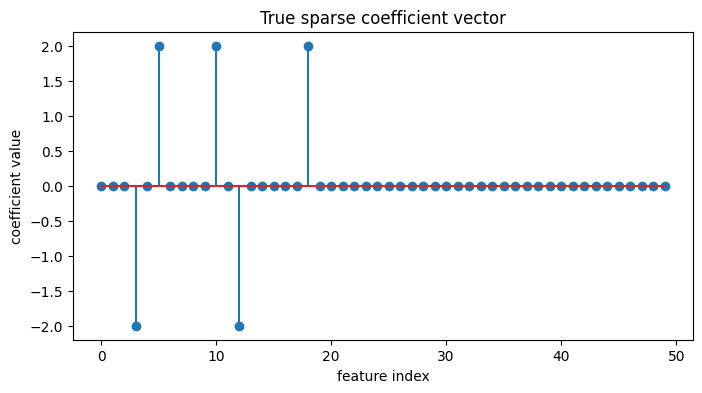

In [9]:
plt.figure(figsize=(8,4))
plt.stem(w_true)
plt.title("True sparse coefficient vector")
plt.xlabel("feature index")
plt.ylabel("coefficient value")
plt.show()

The plot shows that only 5 coefficients are nonzero, while the remaining coefficients are exactly zero, confirming the sparsity of the true parameter vector.

Using the data generation procedure described above, we obtain a synthetic dataset (X, y), along with the true coefficient vector w* and its support (i.e. nonzero positions), which will serve as the ground truth for evaluating prediction accuracy.

## Experimental Study under Varying Data Conditions

# References
- Marcussena. (n.d.). Synthetic data generation [GitHub repository]. 
https://github.com/Marcussena/Synthetic-data-generation